# Buffett's alpha — the most famous edge in the world, audited 🎩
### Was Warren Buffett's outperformance *real*? And is there any of it left?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Any_alpha_left%3F: Busted](https://img.shields.io/badge/Any_alpha_left%3F-Busted-8b949e?style=flat-square)

Every market legend on this desk so far has been a folk tale, a coin flip, or an accounting trick. This one is different: **Warren Buffett's Berkshire Hathaway** is the single most famous investment track record alive, and in 2013 three quants (Frazzini, Kabiller & Pedersen — 'FKP') published *Buffett's Alpha*, claiming his 40-year edge is **statistically real**, that it comes from buying **safe, high-quality stocks with cheap insurance-money leverage** — and that it has been **fading**.

We audit all three claims on free public data: every month of Berkshire's stock since 1980 against the US market.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the fade regression and the factor loadings? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **One honesty note up front.** Berkshire is on this bench *because it won* — we're grading the most successful survivor of thousands of 1980s conglomerates. The stats certify *his* track record, not your odds of finding the next one.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buffetts_alpha import data, strategy as st

HAVE_REAL = data.have_real()
DF = data.load_real() if HAVE_REAL else None
print("real tape cached:", HAVE_REAL,
      "| months:", (0 if DF is None else len(DF)),
      "| span:", ("-" if DF is None else f"{DF.index.min().date()} -> {DF.index.max().date()}"))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1980-04-30', 'end': '2026-06-30', 'n': 555, 'years': 46.2, 'splice_pre': 154, 'splice_spy': 401, 'wealth_brk': 2880, 'wealth_mkt': 220, 'brk_ann': 18.8, 'mkt_ann': 12.37, 'alpha_ann': 9.46, 't_alpha': 3.47, 'beta': 0.7, 'r2': 0.24, 'ir': 0.5, 'nw_lags': 5, 'brk_exc': 15.64, 'mkt_exc': 8.88, 'brk_sharpe': 0.72, 'mkt_sharpe': 0.59, 'brk_vol': 21.6, 'fkp': {'alpha': 12.36, 't': 3.4, 'beta': 0.68, 'n': 381, 'brk_sharpe': 0.72, 'mkt_sharpe': 0.44}, 'decades': [('1980s', 23.39, 3.55, 0.82, 31.25, 9.58, 117), ('1990s', 5.07, 0.76, 0.92, 16.7, 12.68, 120), ('2000s', 6.01, 1.28, 0.47, 4.88, -2.41, 120), ('2010s', 5.15, 1.28, 0.6, 12.89, 12.9, 120), ('2020s*', 2.06, 0.34, 0.71, 11.4, 13.13, 78)], 'roll': {'n_windows': 436, 'first': '1990-03-31', 'peak': 20.34, 'peak_at': '1990-03-31', 'latest': 1.83, 'latest_t': 0.46, 'latest_beta': 0.75, 'last_sig': '2002-12-31', 'share_sig': 25.0}, 'fade': {'early_alpha': 12.97, 'early_t': 3.48, 'd_alpha': -10.98, 'd_t': -2.38, 'd_beta': 0.08, 'd_beta_t': 0.65, 'split': '2010-12-31'}, 'last15': {'alpha': 2.66, 't': 0.89, 'beta': 0.75, 'n': 180, 'brk_sharpe': 0.74, 'mkt_sharpe': 0.9, 'wealth_brk': 6.45, 'wealth_mkt': 7.37, 'start': '2011-07-31'}, 'flite': {'start': '2013-08-31', 'n': 155, 'capm_alpha': 1.54, 'capm_t': 0.46, 'capm_beta': 0.75, 'r2_capm': 0.41, 'full_alpha': 1.43, 'full_t': 0.44, 'r2_full': 0.51, 'b_mkt': -0.17, 't_mkt': -0.37, 'b_qual': 0.3, 't_qual': 0.68, 'b_usmv': 0.89, 't_usmv': 3.77}, 'syn': [(0.0, 0.27, 0.11, 10), (6.0, 6.27, 2.56, 70)], 'fingerprint': '96d18b13a5da'}


real tape cached: True | months: 555 | span: 1980-04-30 -> 2026-06-30


## The answer first

| Question | Answer |
|---|---|
| Was the alpha real? | **Yes.** $1 in Berkshire in 1980 became **$2,880** vs the market's **$220** — and the statistics say luck can't explain it (the quants' *t* is **3.5**, well past the desk bar of 2). |
| Where did it live? | Overwhelmingly the **1980s** (+23%/yr of pure skill). Every decade since is statistically indistinguishable from a passive index fund. |
| Is any left? | **No.** Over the last 15 years Berkshire *lagged* the S&P 500 ($6.45 vs $7.37 per dollar) with zero measurable alpha. |

The chart below is the whole legend in one picture — note the **log scale**: each gridline is 10× the one below.

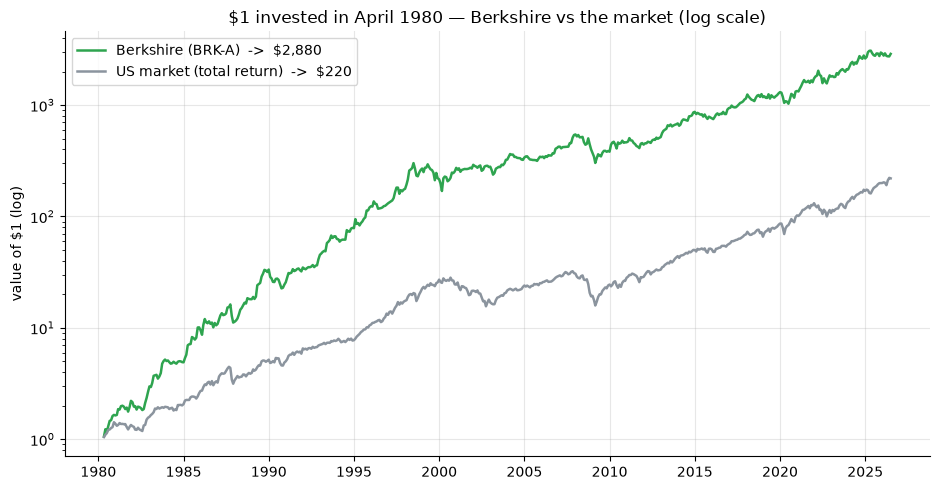

In [2]:
if HAVE_REAL:
    w_brk = (1 + DF['brk']).cumprod()
    w_mkt = (1 + DF['mkt']).cumprod()
    fig, ax = plt.subplots()
    ax.plot(w_brk.index, w_brk, color=GREEN, lw=1.8,
            label=f"Berkshire (BRK-A)  ->  ${R['wealth_brk']:,}")
    ax.plot(w_mkt.index, w_mkt, color=GREY, lw=1.8,
            label=f"US market (total return)  ->  ${R['wealth_mkt']:,}")
    ax.set_yscale('log')
    ax.set_title('$1 invested in April 1980 — Berkshire vs the market (log scale)')
    ax.set_ylabel('value of $1 (log)')
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('cache missing — headline: $1 -> $2,880 (BRK) vs $220 (market)')

## What 'alpha' actually means here

'Beating the market' isn't enough — you can beat it by simply borrowing and taking more risk. **Alpha** is the outperformance *left over* after accounting for how much market risk you took (**beta**). Buffett's numbers are strange in the best way:

- his beta is only **0.70** — Berkshire moves *less* than the market,
- yet he out-earned it by **+6.8 points a year** over 46 years,
- leaving an alpha of **+9.5%/yr** that risk cannot explain.

That is exactly FKP's signature: **safe stocks, levered with cheap insurance float** — less risk than the index, more return.

> 🔬 **For the quants.** Full-sample excess-vs-excess CAPM, Newey-West HAC: alpha +9.46%/yr, *t* = 3.47, beta 0.70, n = 555. On FKP's own era (→ 2011): alpha +12.36%/yr, *t* = 3.40 — their '*t* > 3' replicates.

## Where the magic lived — decade by decade

Split the 46 years into decades and the legend gets a timestamp: the skill is **front-loaded**. The 1980s alone carry a staggering +23%/yr of alpha; from the 1990s on, every bar could be zero (the error bars — the honest 'could be luck' range — cross the axis).

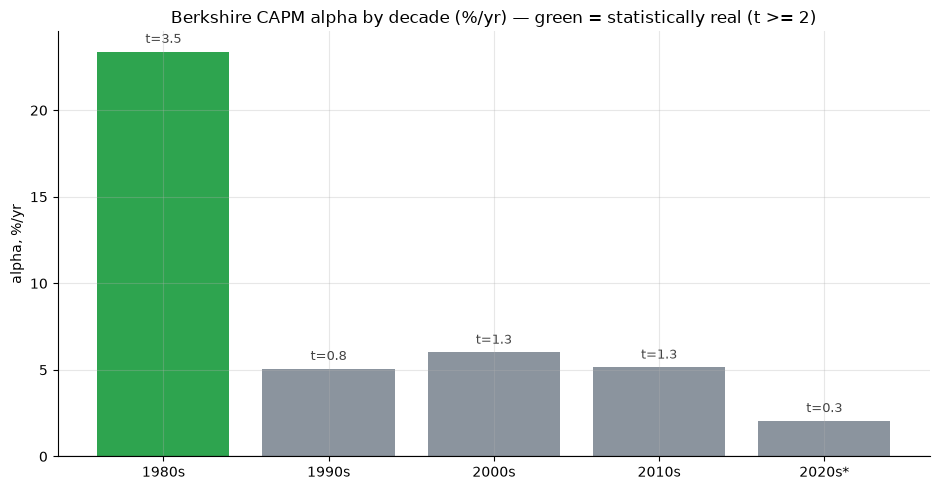

* 2020s = partial decade (78 months)


In [3]:
decs = R['decades']
labels = [d[0] for d in decs]; alphas = [d[1] for d in decs]; ts = [d[2] for d in decs]
colors = [GREEN if t >= 2 else GREY for t in ts]
fig, ax = plt.subplots()
bars = ax.bar(labels, alphas, color=colors)
for b, t in zip(bars, ts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f't={t:.1f}',
            ha='center', fontsize=9, color='#444')
ax.axhline(0, color='k', lw=.8)
ax.set_title('Berkshire CAPM alpha by decade (%/yr) — green = statistically real (t >= 2)')
ax.set_ylabel('alpha, %/yr')
plt.tight_layout(); plt.show()
print('* 2020s = partial decade (78 months)')

## The fade, filmed in slow motion

A fairer camera than decades: at every month we look back at the **previous 10 years** and ask 'was there alpha in this window?'. The curve starts near +20%/yr and dies on the axis. The last 10-year window that *statistically* certified alpha ended in **2002** — over twenty years ago.

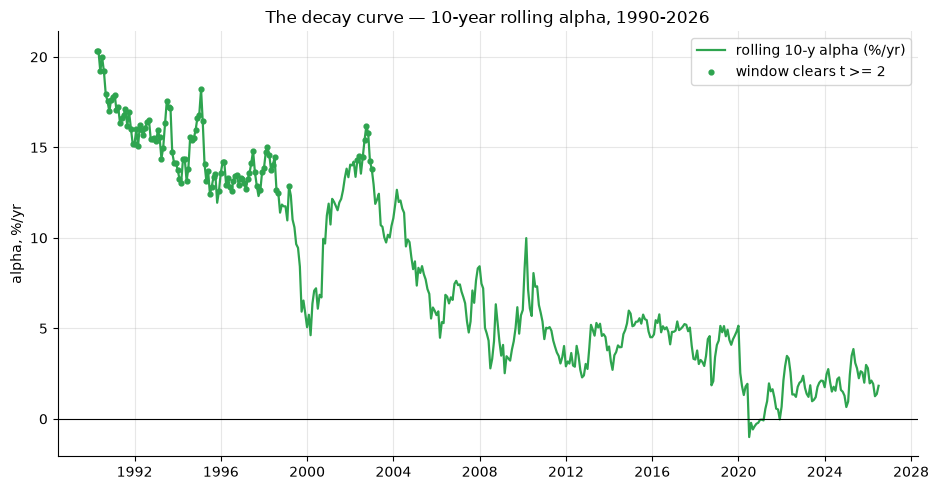

peak +20.3%/yr | latest +1.8%/yr | last significant window ends 2002-12-31


In [4]:
if HAVE_REAL:
    ra = st.rolling_alpha(DF, window=120)
    fig, ax = plt.subplots()
    ax.plot(ra.index, ra['alpha_ann_pct'], color=GREEN, lw=1.6, label='rolling 10-y alpha (%/yr)')
    sig = ra[ra['t_alpha'] >= 2]
    ax.scatter(sig.index, sig['alpha_ann_pct'], s=12, color=GREEN, zorder=3,
               label='window clears t >= 2')
    ax.axhline(0, color='k', lw=.8)
    ax.set_title('The decay curve — 10-year rolling alpha, 1990-2026')
    ax.set_ylabel('alpha, %/yr'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"peak {ra['alpha_ann_pct'].max():+.1f}%/yr | latest "
          f"{ra['alpha_ann_pct'].iloc[-1]:+.1f}%/yr | last significant window ends "
          f"{ra[ra['t_alpha'] >= 2].index.max().date()}")
else:
    print('cache missing — peak +20.3%/yr (1990), latest +1.8%/yr, last t>=2 window ends 2002-12')

## The last 15 years — buying the museum, not the artist

Since mid-2011: alpha **+2.7%/yr** with *t* = 0.89 — statistically **zero**. Berkshire's risk-adjusted score (Sharpe **0.74**) is now *below* the index's (**0.90**), and a dollar in Berkshire grew to **$6.45** vs **$7.37** in the S&P 500. What does Berkshire trade like today? A **minimum-volatility index fund** — in the quants' regression it tracks the min-vol ETF (USMV) more decisively than anything else. Exactly what FKP predicted: the style is copyable, the leverage advantage shrank with size, and $1T of assets can't dart in and out of bargains.

> 💡 Buffett himself has said it for years in the shareholder letters: *'size is the anchor of performance.'* The tape agrees with him.

## Takeaway

1. **The legend is real.** Buffett's alpha is the rare one that survives a hostile audit: +9.5%/yr of genuine, risk-adjusted skill over 46 years (*t* = 3.5).
2. **It's history.** The skill lives in the 1980s; no 10-year stretch since 2002 certifies alpha, and the fade itself is statistically significant.
3. **You can't buy it.** BRK-B costs a click — but what the click buys is a giant, well-run, low-beta conglomerate that has *lagged* the index for 15 years. The alpha belongs to the man, the era, and the float — not to today's shareholder.

*Selection note (repeated on purpose): we graded the winner. Thousands of 1980s conglomerates went to zero un-audited.*

---
*Study 628 of [Open-Alpha-Lab](../../../README.md). Numbers: [docs/results.md](../docs/results.md) (as-of 2026-06-30, fingerprint `96d18b13a5da`). Not investment advice.*